In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoModel, AutoTokenizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load the test dataset (same one used for fine-tuned evaluation)
print("Loading test dataset...")
test_data = torch.load("ebm_nlp_test_tokenized.pt", weights_only=False)
test_dataloader = DataLoader(test_data, batch_size=8, shuffle=False)

LABEL_NAMES = ["Complete", "Missing P", "Missing I", "Missing O"]
print(f"Test set size: {len(test_data)} samples")


c:\Users\erank\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Loading test dataset...
Test set size: 189 samples


In [2]:
# Load untrained BioBERT with a fresh, randomly initialized classification head
print("Loading untrained BioBERT with random classification head...")
untrained_model = AutoModelForSequenceClassification.from_pretrained(
    "dmis-lab/biobert-base-cased-v1.2",
    num_labels=4
)
untrained_model.to(device)
untrained_model.eval()

# Run inference — no training has happened, classifier weights are random
all_preds = []
all_labels = []

print("Running untrained model on test set...")
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = untrained_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Results
untrained_accuracy = np.mean(all_preds == all_labels)
print(f"\n{'='*50}")
print(f"UNTRAINED BioBERT BASELINE")
print(f"{'='*50}")
print(f"Accuracy: {untrained_accuracy:.4f} ({untrained_accuracy*100:.1f}%)")
print(f"Expected random chance: {1/4:.4f} (25.0%)")
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES))
print(f"Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


Loading untrained BioBERT with random classification head...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-base-cased-v1.2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Running untrained model on test set...

UNTRAINED BioBERT BASELINE
Accuracy: 0.1217 (12.2%)
Expected random chance: 0.2500 (25.0%)

Classification Report:
              precision    recall  f1-score   support

    Complete       0.00      0.00      0.00        95
   Missing P       0.00      0.00      0.00        40
   Missing I       0.12      1.00      0.22        23
   Missing O       0.00      0.00      0.00        31

    accuracy                           0.12       189
   macro avg       0.03      0.25      0.05       189
weighted avg       0.01      0.12      0.03       189

Confusion Matrix:
[[ 0  0 95  0]
 [ 0  0 40  0]
 [ 0  0 23  0]
 [ 0  0 31  0]]


In [3]:
def extract_cls_embeddings(model, dataloader, device):
    """Extract [CLS] token embeddings (hidden state at position 0) from the encoder."""
    model.eval()
    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels']

            # Get the base model's hidden states (not the classification logits)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)

            # [CLS] token is at position 0 of the last hidden layer
            cls_embeddings = outputs.hidden_states[-1][:, 0, :]  # shape: (batch, 768)

            all_embeddings.append(cls_embeddings.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.vstack(all_embeddings), np.array(all_labels)


# --- Extract embeddings from UNTRAINED BioBERT ---
print("Extracting [CLS] embeddings from UNTRAINED BioBERT...")
untrained_embeddings, labels = extract_cls_embeddings(untrained_model, test_dataloader, device)
print(f"  Shape: {untrained_embeddings.shape}")

# --- Load and extract embeddings from FINE-TUNED BioBERT ---
print("\nLoading fine-tuned BioBERT...")
finetuned_model = AutoModelForSequenceClassification.from_pretrained("./saved_biobert_pico_model/")
finetuned_model.to(device)
finetuned_model.eval()

print("Extracting [CLS] embeddings from FINE-TUNED BioBERT...")
finetuned_embeddings, _ = extract_cls_embeddings(finetuned_model, test_dataloader, device)
print(f"  Shape: {finetuned_embeddings.shape}")


Extracting [CLS] embeddings from UNTRAINED BioBERT...
  Shape: (189, 768)

Loading fine-tuned BioBERT...
Extracting [CLS] embeddings from FINE-TUNED BioBERT...
  Shape: (189, 768)


Running t-SNE on untrained embeddings...
Running t-SNE on fine-tuned embeddings...


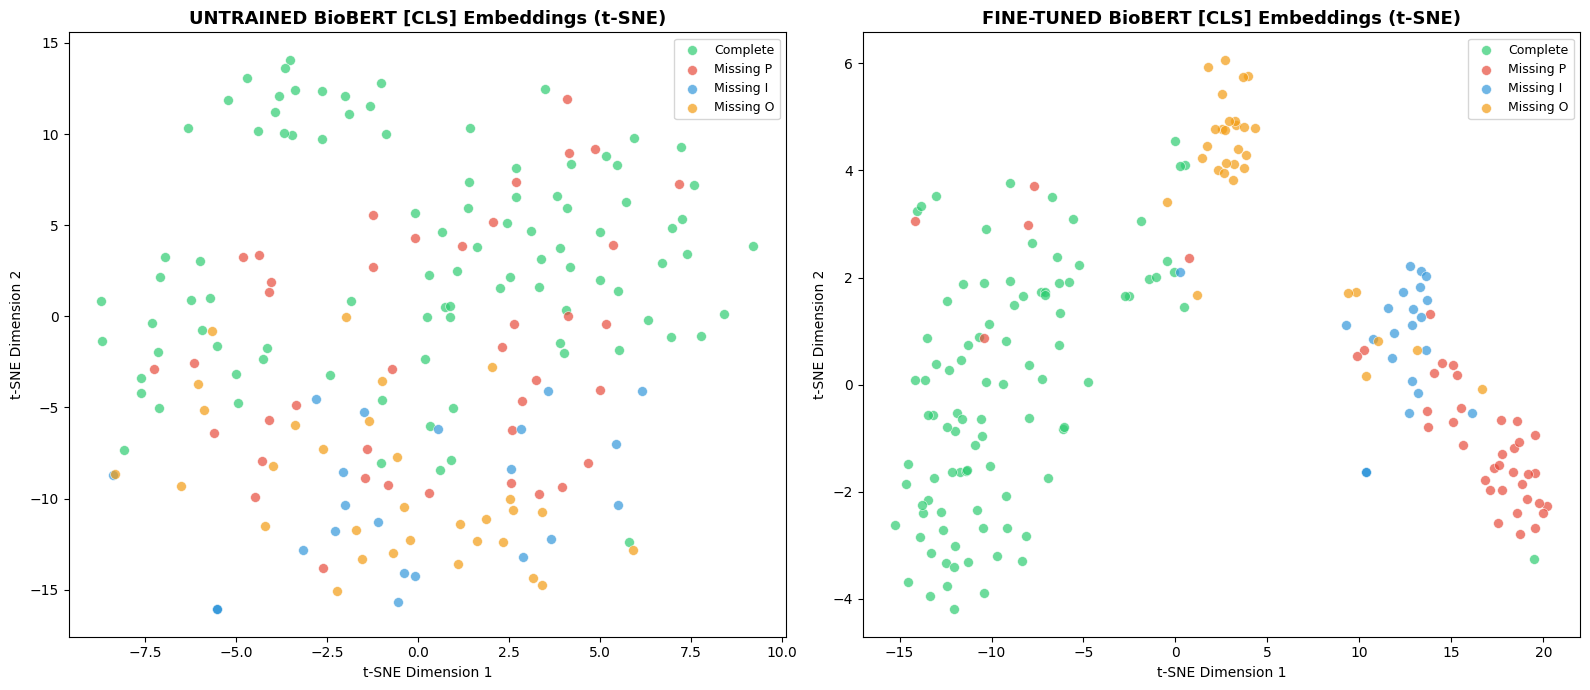

Saved: tsne_before_after_finetuning.png


In [4]:
# t-SNE reduction to 2D
print("Running t-SNE on untrained embeddings...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
untrained_tsne = tsne.fit_transform(untrained_embeddings)

print("Running t-SNE on fine-tuned embeddings...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
finetuned_tsne = tsne.fit_transform(finetuned_embeddings)

# Plot side by side
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']  # green, red, blue, orange

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for class_id in range(4):
    mask = labels == class_id
    axes[0].scatter(
        untrained_tsne[mask, 0], untrained_tsne[mask, 1],
        c=colors[class_id], label=LABEL_NAMES[class_id],
        alpha=0.7, s=50, edgecolors='white', linewidth=0.5
    )
    axes[1].scatter(
        finetuned_tsne[mask, 0], finetuned_tsne[mask, 1],
        c=colors[class_id], label=LABEL_NAMES[class_id],
        alpha=0.7, s=50, edgecolors='white', linewidth=0.5
    )

axes[0].set_title("UNTRAINED BioBERT [CLS] Embeddings (t-SNE)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("t-SNE Dimension 1")
axes[0].set_ylabel("t-SNE Dimension 2")
axes[0].legend(fontsize=9)

axes[1].set_title("FINE-TUNED BioBERT [CLS] Embeddings (t-SNE)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("tsne_before_after_finetuning.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: tsne_before_after_finetuning.png")


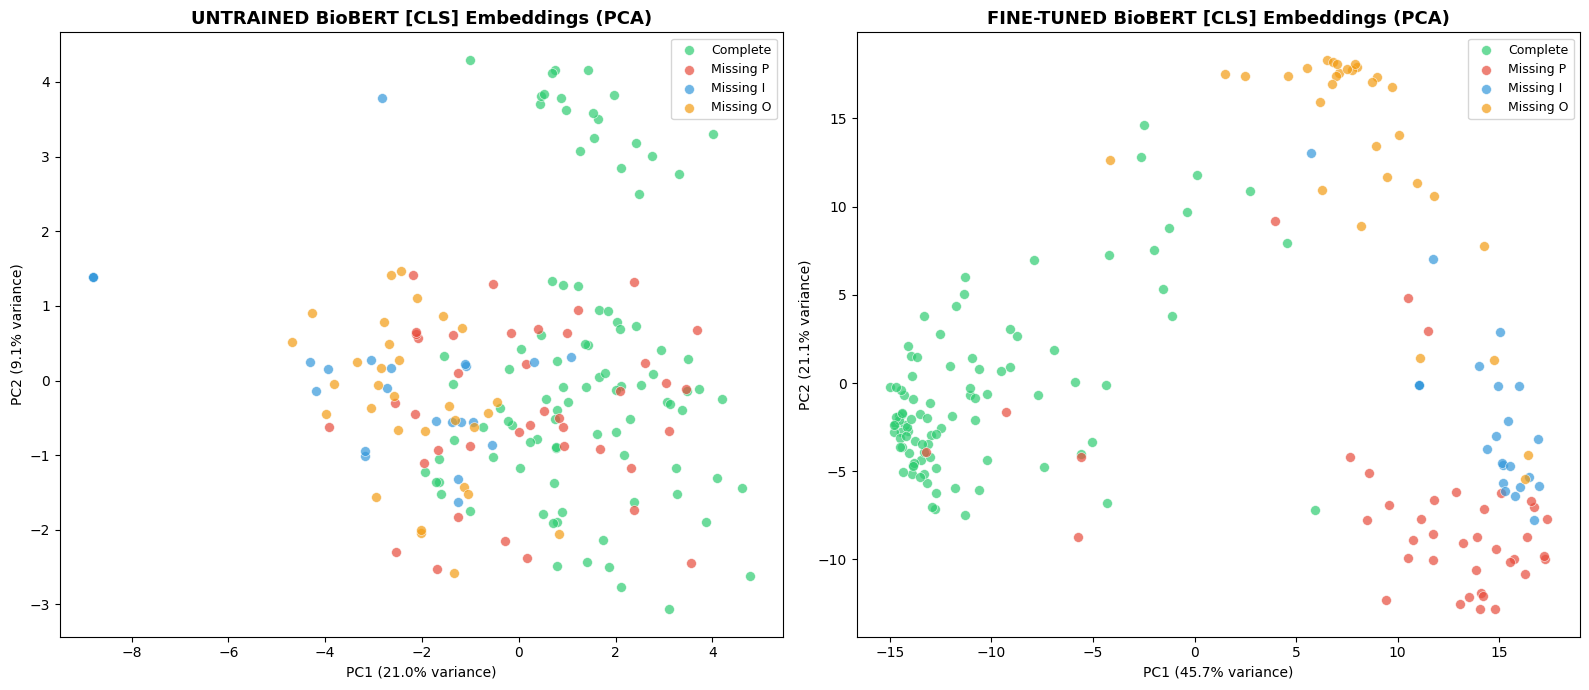

Saved: pca_before_after_finetuning.png


In [5]:
# PCA reduction to 2D
pca = PCA(n_components=2, random_state=42)
untrained_pca = pca.fit_transform(untrained_embeddings)
untrained_var = pca.explained_variance_ratio_

pca = PCA(n_components=2, random_state=42)
finetuned_pca = pca.fit_transform(finetuned_embeddings)
finetuned_var = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for class_id in range(4):
    mask = labels == class_id
    axes[0].scatter(
        untrained_pca[mask, 0], untrained_pca[mask, 1],
        c=colors[class_id], label=LABEL_NAMES[class_id],
        alpha=0.7, s=50, edgecolors='white', linewidth=0.5
    )
    axes[1].scatter(
        finetuned_pca[mask, 0], finetuned_pca[mask, 1],
        c=colors[class_id], label=LABEL_NAMES[class_id],
        alpha=0.7, s=50, edgecolors='white', linewidth=0.5
    )

axes[0].set_title("UNTRAINED BioBERT [CLS] Embeddings (PCA)", fontsize=13, fontweight='bold')
axes[0].set_xlabel(f"PC1 ({untrained_var[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({untrained_var[1]*100:.1f}% variance)")
axes[0].legend(fontsize=9)

axes[1].set_title("FINE-TUNED BioBERT [CLS] Embeddings (PCA)", fontsize=13, fontweight='bold')
axes[1].set_xlabel(f"PC1 ({finetuned_var[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({finetuned_var[1]*100:.1f}% variance)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("pca_before_after_finetuning.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: pca_before_after_finetuning.png")


In [6]:
# Run fine-tuned model on same test set for direct comparison
ft_preds = []
ft_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        batch_labels = batch['labels'].to(device)

        outputs = finetuned_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        ft_preds.extend(preds.cpu().numpy())
        ft_labels.extend(batch_labels.cpu().numpy())

ft_preds = np.array(ft_preds)
ft_labels = np.array(ft_labels)
finetuned_accuracy = np.mean(ft_preds == ft_labels)

# Print final comparison
print("=" * 60)
print("BASELINE COMPARISON: Untrained vs Fine-Tuned BioBERT")
print("=" * 60)
print(f"{'Model':<30} {'Accuracy':>10}")
print("-" * 42)
print(f"{'Random Chance (theoretical)':<30} {'25.00%':>10}")
print(f"{'Untrained BioBERT':<30} {f'{untrained_accuracy*100:.2f}%':>10}")
print(f"{'Fine-Tuned BioBERT (ours)':<30} {f'{finetuned_accuracy*100:.2f}%':>10}")
print("-" * 42)
print(f"{'Improvement from fine-tuning':<30} {f'+{(finetuned_accuracy - untrained_accuracy)*100:.2f}%':>10}")
print(f"\nConclusion: Fine-tuning improved accuracy by {(finetuned_accuracy - untrained_accuracy)*100:.1f} percentage points,")
print(f"confirming the untrained encoder has no meaningful PICO classification ability.")


BASELINE COMPARISON: Untrained vs Fine-Tuned BioBERT
Model                            Accuracy
------------------------------------------
Random Chance (theoretical)        25.00%
Untrained BioBERT                  12.17%
Fine-Tuned BioBERT (ours)          82.54%
------------------------------------------
Improvement from fine-tuning      +70.37%

Conclusion: Fine-tuning improved accuracy by 70.4 percentage points,
confirming the untrained encoder has no meaningful PICO classification ability.
